In [1]:
import pandas as pd 
import tensorflow_datasets as tfds

df, _ = tfds.load('YelpPolarityReviews', as_supervised=True,with_info=True)
# Convert the dataset to a pandas DataFrame
def dataset_to_dataframe(dataset):
    data = []

    for text, label in dataset:
        sentiment = 'positive' if label.numpy() == 1 else 'negative'
        data.append((text.numpy().decode('utf-8'), sentiment))

    df = pd.DataFrame(data, columns=['review','sentiment'])
    return df

# Covert training and testing datasets to DataFrames
df = dataset_to_dataframe(df['train'])



In [2]:
df.head()

,review,sentiment
0,The Groovy P. and I ventured to his old stompi...,positive
1,Mediocre burgers - if you are in the area and ...,negative
2,Not at all impressed...our server was not very...,negative
3,I wish I would have read Megan P's review befo...,negative
4,A large selection of food from all over the wo...,positive


In [3]:
print(len(df))

560000


In [4]:
df = df.dropna()
print(len(df))

560000


In [5]:
df.iloc[0]["review"]

"The Groovy P. and I ventured to his old stomping grounds for lunch today.  The '5 and Diner' on 16th St and Colter left me with little to ask for.  Before coming here I had a preconceived notion that 5 & Diners were dirty and nasty. Not the case at all.\\n\\nWe walk in and let the waitress know we want to sit outside (since it's so nice and they had misters).  We get two different servers bringing us stuff (talk about service) and I ask the one waitress for recommendations.  I didn't listen to her, of course, and ordered the Southwestern Burger w/ coleslaw and started with a nice stack of rings.\\n\\nThe Onion Rings were perfectly cooked.  They looked like they were prepackaged, but they were very crispy and I could actually bite through the onion without pulling the entire thing out (don't you hate that?!!!)\\n\\nThe Southwestern Burger was order Medium Rare and was cooked accordingly.  Soft, juicy, and pink with a nice crispy browned outer layer that can only be achieved on a well u

In [6]:
df.iloc[0]["sentiment"]

'positive'

In [7]:
df.iloc[3]["review"]

"I wish I would have read Megan P's review before I decided to cancel my dinner reservations because I was offered a COMP dinner at Beso.  \\n\\nTwo of my girlfriends and I were walking around Fashion Show Mall as a promoter approaches us to ask if we'd like to go to Eve Nightclub that night.  We wanted to go to Haze and XS so we declined.  The promoter (by the way - his name is ANDRE) offers us a comp dinner at Beso Eva Longoria's restaurant at Crystals Mall.  I guess what's the catch right?  Is there a comp limit and we have to pay after we hit the limit?  No, it's a set dinner.  He sets everything up and promises he'll even walk us into Haze and XS afterwards (which I actually believed).  \\n\\nHere's a review for ANDRE:\\nHe tells you to call him when you're at the restaurant to get you seated.  Well - he doesn't even pick up or return text messages.  Basically, I never even see him again since he approached us at Fashion Show Mall.  He never came to give us our bottle of campagne 

In [8]:
df.iloc[3]["sentiment"]

'negative'

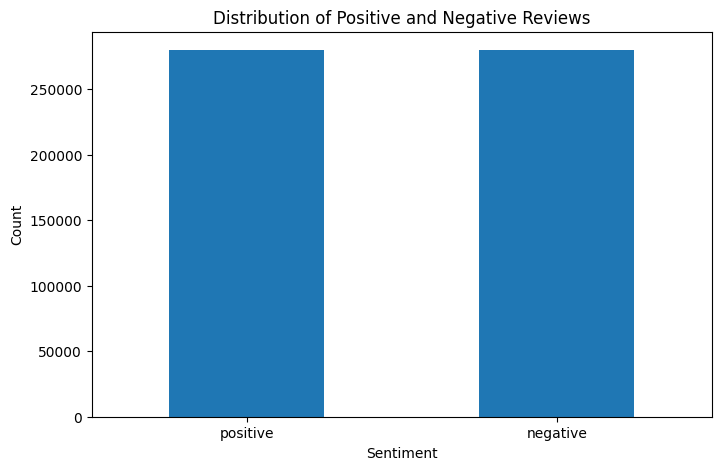

In [9]:
import matplotlib.pyplot as plt
sentiment_counts = df['sentiment'].value_counts()

# Plotting the distribution of sentiments
plt.figure(figsize=(8,5))
sentiment_counts.plot(kind='bar')
plt.title('Distribution of Positive and Negative Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


In [10]:
# Now I am trying to solve this NLP problem using basic ML model.

# steps to solve NLP problem using basic ML model:
# Text --> cleaning -->  convert in numerical format  --> ML model --> evaluation

**Cleaning**

In [11]:
#Examples 
from bs4 import BeautifulSoup

# simples text with html tags
text_with_html = "<p> this is a sample <b>Food</b> review.</p>"
# Remove HTML tags using BeautifulSoup
text_without_html = BeautifulSoup(text_with_html, 'html.parser').get_text()
print("Text without HTML tag:",text_without_html)

Text without HTML tag:  this is a sample Food review.


In [12]:
# remove additional characters except digits and alphabets ; Covert letters to lowercase for standardization
from bs4 import BeautifulSoup
import re  # regular expression
# remove html tags
df['review'] = df['review'].apply(lambda x: BeautifulSoup(x, 'html.parser').get_text())

# covert to lowercase
df['review'] = df['review'].apply(lambda x: x.lower())

# Remove punctuation and non- alphanumeric characters
df['review'] = df['review'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x))

df.head()

#

C:\Users\Abhinesh Singh\AppData\Local\Temp\ipykernel_9048\3595286519.py:5: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a URL than HTML or XML.

If you meant to use Beautiful Soup to parse the web page found at a certain URL, then something has gone wrong. You should use an Python package like 'requests' to fetch the content behind the URL. Once you have the content as a string, you can feed that string into Beautiful Soup.

However, if you want to parse some data that happens to look like a URL, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  df['review'] = df['review'].apply(lambda x: BeautifulSoup(x, 'html.parser').get_text())
C:\Users\

,review,sentiment
0,the groovy p and i ventured to his old stompin...,positive
1,mediocre burgers if you are in the area and w...,negative
2,not at all impressedour server was not very ha...,negative
3,i wish i would have read megan ps review befor...,negative
4,a large selection of food from all over the wo...,positive


**Tokenization:**


In [13]:
# Example of tokenization using nltk library
# Import the Natural Language Toolkit (nltk) library
import nltk

# Import the word_tokenize function from the nltk.tokenize module
from nltk.tokenize import word_tokenize

# Sample text
sample_text  = "This is a random text."

#Tokenize the text using word_tokenize function
tokens = word_tokenize(sample_text)

# now print the list of tokens
print ("Tokens:", tokens)

Tokens: ['This', 'is', 'a', 'random', 'text', '.']


In [14]:
# tokenization
df['review'] = df['review'].apply(lambda x: word_tokenize(x))

In [15]:
df.head()

,review,sentiment
0,"[the, groovy, p, and, i, ventured, to, his, ol...",positive
1,"[mediocre, burgers, if, you, are, in, the, are...",negative
2,"[not, at, all, impressedour, server, was, not,...",negative
3,"[i, wish, i, would, have, read, megan, ps, rev...",negative
4,"[a, large, selection, of, food, from, all, ove...",positive


**Stopword Removal:**

In [16]:
from nltk.corpus import stopwords
nltk.download('stopwords')
# reomove stopwords - I is am are was were be  etc like that words are called stopwords.
# They do not add much meaning to the text and can be removed to reduce noise in the data.
stop_words = set(stopwords.words('english'))
df['review'] = df['review'].apply(lambda x: [word for word in x if word not in stop_words])

df.head()

[nltk_data] Downloading package stopwords to C:\Users\Abhinesh
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review,sentiment
0,"[groovy, p, ventured, old, stomping, grounds, ...",positive
1,"[mediocre, burgers, area, want, fast, food, bu...",negative
2,"[impressedour, server, happy, therefood, subpa...",negative
3,"[wish, would, read, megan, ps, review, decided...",negative
4,"[large, selection, food, world, great, atmosph...",positive


**Lemmatization** 

In [18]:
#Example of lemmatization using nltk library
# Impprt the wordNetLemmatizer from the nltk.stem module
from nltk.stem import WordNetLemmatizer

# Import the word_tokenize function from the nltk.tokenize module
from nltk.tokenize import word_tokenize

import nltk
nltk.download('wordnet')

# create an instance of the WordNetLemmatizer
lemmantizer = WordNetLemmatizer()

# example sentence
sentence = "The quick brown foxes are jumping over the lazy dogs."
# tokenize the sentence
tokens = word_tokenize(sentence)

# lemmatize the token
lemmatized_tokens = [lemmantizer.lemmatize(word) for word in tokens]
print("Original Tokens:", tokens)
print("Lemmatized Tokens:", lemmatized_tokens)

[nltk_data] Downloading package wordnet to C:\Users\Abhinesh
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Original Tokens: ['The', 'quick', 'brown', 'foxes', 'are', 'jumping', 'over', 'the', 'lazy', 'dogs', '.']
Lemmatized Tokens: ['The', 'quick', 'brown', 'fox', 'are', 'jumping', 'over', 'the', 'lazy', 'dog', '.']


In [19]:
from nltk.stem import WordNetLemmatizer
# download NLTK resources (if not already downloaded)
nltk.download('wordnet')

#Lemmatization
lemmantizer = WordNetLemmatizer()
df['review'] = df['review'].apply(lambda x: [lemmantizer. lemmatize(word) for word in x])

# covert list of tokens back to string
df['review'] = df['review'].apply(lambda x: ' '.join(x))

df.head()

[nltk_data] Downloading package wordnet to C:\Users\Abhinesh
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,review,sentiment
0,groovy p ventured old stomping ground lunch to...,positive
1,mediocre burger area want fast food burger fat...,negative
2,impressedour server happy therefood subpar way...,negative
3,wish would read megan p review decided cancel ...,negative
4,large selection food world great atmosphere am...,positive


**Now Step is to covert text in numerical format.**


Bow, tfidf ---> covert only Sentences to numerical 

BoW = Bag of Words,
TF-IDF = Term Frequency – Inverse Document Frequency

In [ ]:
# Bag of Words (BoW) Vectorization
from sklearn.feature_extraction.text import CountVectorizer

# create a countvectorizer object
count_vectorizer = CountVectorizer()

# fit and transform the text data to obtain the count vector representation
count_vector = count_vectorizer.fit_transform(df['review'])

# convert the count vector to an array
#count_vector_array = count_vector.toarray()  
# beacause it will consume a lot of memory if the dataset is large, 
# so we can convert only a subset of the count vector to an array for demonstration purposes.
count_vector_array = count_vector[:5].toarray()

print("Count Vector Array:\n", count_vector_array)

Count Vector Array:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [22]:
print(len(df))

560000


In [23]:
df['review'].iloc[3]

'wish would read megan p review decided cancel dinner reservation offered comp dinner beso nntwo girlfriend walking around fashion show mall promoter approach u ask wed like go eve nightclub night wanted go haze x declined promoter way name andre offer u comp dinner beso eva longorias restaurant crystal mall guess whats catch right comp limit pay hit limit set dinner set everything promise hell even walk u haze x afterwards actually believed nnheres review andrenhe tell call youre restaurant get seated well doesnt even pick return text message basically never even see since approached u fashion show mall never came give u bottle campagne promised either never show walk u haze set u x top gave number promoter lavo without letting know guess promoter get paid number girl pull ive definitely dealt reliable promoter actually keep word nnheres review meal nwe party 9 girl ordered cocktail 15 4 sodaiced teaetc ordered ginger cosmo id say id definitely order menu highly recommended waitress w

In [24]:
print(count_vector[3])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 199 stored elements and shape (1, 727233)>
  Coords	Values
  (0, 365287)	1
  (0, 59177)	1
  (0, 692674)	3
  (0, 692117)	1
  (0, 348708)	1
  (0, 693744)	4
  (0, 581871)	1
  (0, 270345)	4
  (0, 185087)	1
  (0, 460857)	2
  (0, 362137)	2
  (0, 32792)	3
  (0, 90132)	1
  (0, 710435)	1
  (0, 196844)	3
  (0, 460768)	1
  (0, 701227)	1
  (0, 60756)	1
  (0, 522602)	2
  (0, 276068)	2
  (0, 281530)	1
  (0, 655851)	1
  (0, 647725)	2
  (0, 274164)	5
  (0, 6004)	1
  :	:
  (0, 186702)	1
  (0, 307606)	1
  (0, 629667)	1
  (0, 554094)	1
  (0, 146717)	1
  (0, 208188)	1
  (0, 485934)	1
  (0, 720273)	1
  (0, 416880)	1
  (0, 627461)	1
  (0, 28269)	1
  (0, 142106)	2
  (0, 42111)	1
  (0, 663852)	1
  (0, 394085)	1
  (0, 520951)	1
  (0, 214168)	1
  (0, 608818)	1
  (0, 252785)	1
  (0, 436894)	1
  (0, 707958)	2
  (0, 308492)	1
  (0, 368522)	1
  (0, 548250)	1
  (0, 720084)	1


In [25]:
# TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Sample documents with simple day-to-day sentences
documents = [
    "Apples are delicious fruits that are enjoyed by many people.",
    "Bananas are a popular choice for a healthy snack.",
    "Oranges are juicy citrus fruits rich in vitamin C.",
    "Grapes are small, sweet berries often used to make juice or wine."
]

# Initialize the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the documents to TF-IDF vectors
tfidf_vectors = tfidf_vectorizer.fit_transform(documents)

# Get the vocabulary (terms)
vocabulary = tfidf_vectorizer.get_feature_names_out()

# Display TF-IDF vectors for each document
for i, document in enumerate(documents):
    print(f"TF-IDF Vector for Document {i+1}:")
    for term, tfidf_value in zip(vocabulary, tfidf_vectors.toarray()[i]):
        print(f"{term}: {tfidf_value:.3f}")
    print()

TF-IDF Vector for Document 1:
apples: 0.339
are: 0.354
bananas: 0.000
berries: 0.000
by: 0.339
choice: 0.000
citrus: 0.000
delicious: 0.339
enjoyed: 0.339
for: 0.000
fruits: 0.267
grapes: 0.000
healthy: 0.000
in: 0.000
juice: 0.000
juicy: 0.000
make: 0.000
many: 0.339
often: 0.000
or: 0.000
oranges: 0.000
people: 0.339
popular: 0.000
rich: 0.000
small: 0.000
snack: 0.000
sweet: 0.000
that: 0.339
to: 0.000
used: 0.000
vitamin: 0.000
wine: 0.000

TF-IDF Vector for Document 2:
apples: 0.000
are: 0.208
bananas: 0.399
berries: 0.000
by: 0.000
choice: 0.399
citrus: 0.000
delicious: 0.000
enjoyed: 0.000
for: 0.399
fruits: 0.000
grapes: 0.000
healthy: 0.399
in: 0.000
juice: 0.000
juicy: 0.000
make: 0.000
many: 0.000
often: 0.000
or: 0.000
oranges: 0.000
people: 0.000
popular: 0.399
rich: 0.000
small: 0.000
snack: 0.399
sweet: 0.000
that: 0.000
to: 0.000
used: 0.000
vitamin: 0.000
wine: 0.000

TF-IDF Vector for Document 3:
apples: 0.000
are: 0.199
bananas: 0.000
berries: 0.000
by: 0.000
choice:

In [36]:
x = count_vector
# Create a mapping dictionary
label_mapping ={"positive":1, "negative":0}

# covert string labels to numerical labels
y = [label_mapping[label] for label in df['sentiment']]
print(y[:50])

[1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1]


In [37]:
# Naive Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Split the data into training and testing sets
# taking only top 200 reviews
x = x[:1000]
y = y[:1000]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

# Create the MultinomialNB instance
nb_model = MultinomialNB()

# Train the model
nb_model.fit(x_train, y_train)

# Predict the labels for the test set
y_pred = nb_model.predict(x_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.764
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.90      0.80       131
           1       0.85      0.61      0.71       119

    accuracy                           0.76       250
   macro avg       0.78      0.76      0.76       250
weighted avg       0.78      0.76      0.76       250



In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [39]:

# Create the Logistic Regression model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(x_train, y_train)

# Predict the labels for the test set
y_pred = nb_model.predict(x_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.764
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.90      0.80       131
           1       0.85      0.61      0.71       119

    accuracy                           0.76       250
   macro avg       0.78      0.76      0.76       250
weighted avg       0.78      0.76      0.76       250



In [40]:
# Create the SVM model
svc_model = SVC(kernel='linear', random_state=42)

# Train the model
svc_model.fit(x_train, y_train)

# Predict the labels for the test set
y_pred = svc_model.predict(x_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.772
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.75      0.77       131
           1       0.74      0.80      0.77       119

    accuracy                           0.77       250
   macro avg       0.77      0.77      0.77       250
weighted avg       0.77      0.77      0.77       250



In [41]:
# Create the Random Forest model
rfc_model = RandomForestClassifier(random_state=42)

# Train the model
rfc_model.fit(x_train, y_train)

# Predict the labels
y_pred = rfc_model.predict(x_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.868
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       131
           1       0.85      0.88      0.86       119

    accuracy                           0.87       250
   macro avg       0.87      0.87      0.87       250
weighted avg       0.87      0.87      0.87       250



In [45]:
reviews = [
    "food was amazing and delivery was fast",
    "very bad experience food was cold",
    "taste was good but delivery was late",
    "worst food ever",
    "really enjoyed the meal"
]

# Convert reviews using Bag of Words
reviews_vector = count_vectorizer.transform(reviews)

print("----- Model Predictions -----\n")

for i, review in enumerate(reviews):

    vec = reviews_vector[i]

    nb_pred = nb_model.predict(vec)[0]
    lr_pred = lr_model.predict(vec)[0]
    svm_pred = svc_model.predict(vec)[0]
    rf_pred = rfc_model.predict(vec)[0]

    print("Review:", review)
    print("Naive Bayes:", "Positive" if nb_pred == 1 else "Negative")
    print("Logistic Regression:", "Positive" if lr_pred == 1 else "Negative")
    print("SVM:", "Positive" if svm_pred == 1 else "Negative")
    print("Random Forest:", "Positive" if rf_pred == 1 else "Negative")
    print("--------------------------------------\n")

----- Model Predictions -----

Review: food was amazing and delivery was fast
Naive Bayes: Positive
Logistic Regression: Positive
SVM: Positive
Random Forest: Positive
--------------------------------------

Review: very bad experience food was cold
Naive Bayes: Negative
Logistic Regression: Negative
SVM: Negative
Random Forest: Negative
--------------------------------------

Review: taste was good but delivery was late
Naive Bayes: Negative
Logistic Regression: Positive
SVM: Positive
Random Forest: Positive
--------------------------------------

Review: worst food ever
Naive Bayes: Negative
Logistic Regression: Negative
SVM: Negative
Random Forest: Negative
--------------------------------------

Review: really enjoyed the meal
Naive Bayes: Positive
Logistic Regression: Negative
SVM: Negative
Random Forest: Negative
--------------------------------------

